In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score



In [3]:
for dirname,_,filenames in os.walk("./data"):
    for filename in filenames:
        print(os.path.join(dirname,filename))

./data\1749731750055~2.jpg
./data\37082384235_a643fba80d_q.jpg
./data\401.htm
./data\Admin upload sample.txt
./data\AI_csv.csv
./data\ajith.jpg
./data\annual-enterprise-survey-2024-financial-year-provisional (1).csv
./data\annual-enterprise-survey-2024-financial-year-provisional.csv
./data\Baby-Pic1.jpeg
./data\Baby-Pic2.jpg
./data\baby-pic3.jpg
./data\baby-pic4.jpg
./data\car.jpeg
./data\CDCollection.sql
./data\clustering_practice_dataset.csv
./data\companiesmarketcap.com - Companies ranked by Market Cap - CompaniesMarketCap.com.csv
./data\Dataset_supermarket_sales.xlsx
./data\dhanush.jpg
./data\EDA_01.csv
./data\EDA_02.csv
./data\Election_2024_Voters_Data.csv
./data\exam-results-list-excel-table.xlsx
./data\fsi-2006.xlsx
./data\FSI-2023-DOWNLOAD.xlsx
./data\haarcascade_eye.xml
./data\haarcascade_eye_tree_eyeglasses.xml
./data\haarcascade_frontalface_default.xml
./data\haarcascade_russian_plate_number.xml
./data\id_card.jpeg
./data\image3.PNG
./data\index.html
./data\jai.jpeg
./data\j

In [4]:
df = pd.read_csv("./data/KNNAlgorithmDataset.csv")

In [5]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [7]:
df.drop(['id','Unnamed: 32'],axis=1,inplace=True)

X = df.drop('diagnosis',axis=1)
y = df['diagnosis']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [9]:
scores = []

for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, y_pred))

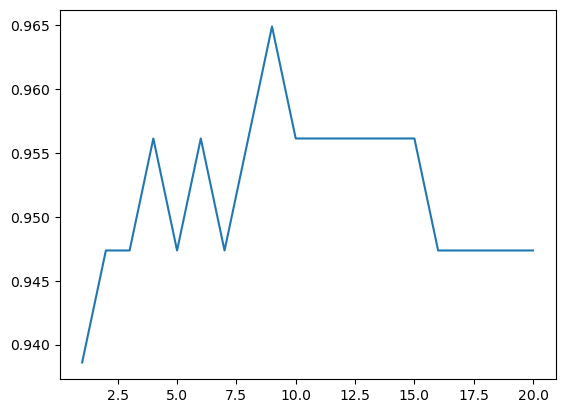

In [10]:
plt.plot(range(1, 21), scores)
plt.show()

In [11]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
print("Accuracy Score:", accuracy_score(y_test, y_pred))

cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("✅ Mean CV Accuracy:", cv_scores.mean())

Accuracy Score: 0.9649122807017544
Cross-validation scores: [0.95604396 0.94505495 0.98901099 0.95604396 0.92307692]
✅ Mean CV Accuracy: 0.9538461538461538
